In [2]:
import pandas as pd
df = pd.read_csv("/scratch/prj0000000262_1/Murata_NYX/AHU 2-9 Blower DE V.csv")

/tmp/ipykernel_1247514/3333087829.py:10: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])


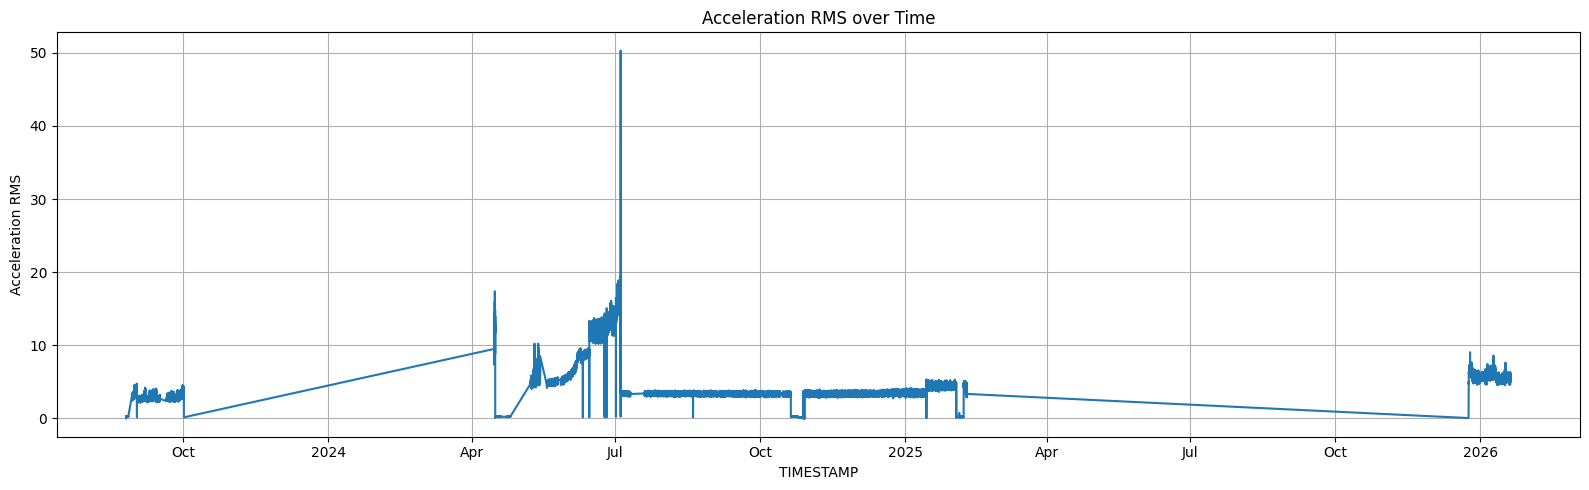

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(
    "/scratch/prj0000000262_1/Murata_NYX/AHU 2-9 Blower DE V.csv"
)

# convert timestamp column to datetime
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

plt.figure(figsize=(16, 5))
plt.plot(df["TIMESTAMP"], df["Acceleration RMS"])
plt.xlabel("TIMESTAMP")
plt.ylabel("Acceleration RMS")
plt.title("Acceleration RMS over Time")
plt.grid(True)

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =========================================================
# 0. CONFIG
# =========================================================
INPUT_LEN = 1024
PRED_LEN = 36

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 64
NUM_EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-5

D_MODEL = 64
NHEAD = 8
NUM_LAYERS = 3
DIM_FEEDFORWARD = 256
DROPOUT = 0.1

MODEL_SAVE_PATH = "transformer_delta_huber_1024_to_36_best.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# =========================================================
# 1. LOAD SERIES
#    df must already exist
# =========================================================
series = df["Acceleration RMS"].to_numpy(dtype=np.float32)
print("Raw series length:", len(series))


# =========================================================
# 2. GLOBAL NORMALIZATION
#    compute from raw train portion only
# =========================================================
train_series_end = int(len(series) * TRAIN_RATIO)
train_mean = series[:train_series_end].mean()
train_std = series[:train_series_end].std() + 1e-8

series_norm = (series - train_mean) / train_std

print("train_mean:", train_mean)
print("train_std :", train_std)


# =========================================================
# 3. DATASET
#    X        : normalized input window
#    y_delta  : normalized future - last_input_value
#
#    X shape  : (N, 1, INPUT_LEN)
#    y shape  : (N, PRED_LEN)
# =========================================================
class MultiStepDeltaDataset(Dataset):
    def __init__(self, series_norm, input_len=1024, pred_len=36):
        series_norm = np.asarray(series_norm, dtype=np.float32)

        self.input_len = input_len
        self.pred_len = pred_len
        self.n_samples = len(series_norm) - input_len - pred_len + 1

        if self.n_samples <= 0:
            raise ValueError("Series too short for given input_len and pred_len.")

        X = np.array(
            [series_norm[i:i + input_len] for i in range(self.n_samples)],
            dtype=np.float32
        )[:, np.newaxis, :]  # (N, 1, input_len)

        future = np.array(
            [series_norm[i + input_len:i + input_len + pred_len] for i in range(self.n_samples)],
            dtype=np.float32
        )  # (N, pred_len)

        last_val = X[:, 0, -1][:, None]   # (N, 1)
        y_delta = future - last_val       # (N, pred_len)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y_delta, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = MultiStepDeltaDataset(series_norm, input_len=INPUT_LEN, pred_len=PRED_LEN)

print("Total samples:", len(dataset))
print("Sample X shape:", dataset[0][0].shape)   # torch.Size([1, 1024])
print("Sample y shape:", dataset[0][1].shape)   # torch.Size([36])


# =========================================================
# 4. CHRONOLOGICAL SPLIT
# =========================================================
n = len(dataset)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_dataset = Subset(dataset, range(0, train_end))
val_dataset = Subset(dataset, range(train_end, val_end))
test_dataset = Subset(dataset, range(val_end, n))

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))


# =========================================================
# 5. DATALOADERS
# =========================================================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# =========================================================
# 6. MODEL
# =========================================================
class TransformerForecastDelta36(nn.Module):
    def __init__(
        self,
        seq_len=1024,
        input_dim=1,
        pred_len=36,
        d_model=64,
        nhead=8,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len)
        )

    def forward(self, x):
        # x: (B, 1, INPUT_LEN)
        x = x.permute(0, 2, 1)              # (B, INPUT_LEN, 1)
        x = self.input_proj(x)              # (B, INPUT_LEN, d_model)
        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.encoder(x)                 # (B, INPUT_LEN, d_model)
        x = self.norm(x)
        x = x[:, -1, :]                     # (B, d_model)
        out = self.head(x)                  # (B, PRED_LEN), predicted delta
        return out


model = TransformerForecastDelta36(
    seq_len=INPUT_LEN,
    input_dim=1,
    pred_len=PRED_LEN,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
).to(DEVICE)


# =========================================================
# 7. LOSS
#    weighted Huber loss
#    earlier horizons get higher weight
# =========================================================
class WeightedHuberLoss(nn.Module):
    def __init__(self, pred_len, delta=1.0):
        super().__init__()
        self.delta = delta
        w = torch.linspace(1.0, 0.3, pred_len, dtype=torch.float32)
        self.register_buffer("w", w / w.mean())

    def forward(self, pred, target):
        w = self.w.to(pred.device)

        err = pred - target
        abs_err = err.abs()
        huber = torch.where(
            abs_err < self.delta,
            0.5 * err ** 2,
            self.delta * (abs_err - 0.5 * self.delta)
        )
        return (huber * w).mean()


criterion = WeightedHuberLoss(pred_len=PRED_LEN, delta=1.0).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(model)


# =========================================================
# 8. TRAIN / VAL LOOP
# =========================================================
def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_count = 0

    with torch.set_grad_enabled(training):
        for x, y_delta in loader:
            x = x.to(device)             # (B, 1, INPUT_LEN)
            y_delta = y_delta.to(device) # (B, PRED_LEN)

            pred_delta = model(x)        # (B, PRED_LEN)
            loss = criterion(pred_delta, y_delta)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count


best_val_loss = float("inf")
best_state = None

for epoch in range(NUM_EPOCHS):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=DEVICE)

    print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
model.to(DEVICE)
model.eval()

print("Best val loss:", best_val_loss)


# =========================================================
# 9. SAVE CHECKPOINT
# =========================================================
checkpoint = {
    "model_state_dict": model.state_dict(),
    "best_val_loss": best_val_loss,
    "train_mean": float(train_mean),
    "train_std": float(train_std),
    "input_len": INPUT_LEN,
    "pred_len": PRED_LEN,
    "model_config": {
        "seq_len": INPUT_LEN,
        "input_dim": 1,
        "pred_len": PRED_LEN,
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "dim_feedforward": DIM_FEEDFORWARD,
        "dropout": DROPOUT,
    }
}
torch.save(checkpoint, MODEL_SAVE_PATH)
print("Saved best model to:", MODEL_SAVE_PATH)


# =========================================================
# 10. COLLECT TEST PREDICTIONS
#
# model outputs delta
# convert:
#   pred_abs_norm = pred_delta + last_val
#   true_abs_norm = y_delta + last_val
# =========================================================
all_preds_abs_norm = []
all_targets_abs_norm = []

model.eval()
with torch.no_grad():
    for x, y_delta in test_loader:
        x = x.to(DEVICE)
        y_delta = y_delta.to(DEVICE)

        pred_delta = model(x)                       # (B, PRED_LEN)
        last_val = x[:, 0, -1].unsqueeze(1)         # (B, 1)

        pred_abs_norm = pred_delta + last_val       # (B, PRED_LEN)
        true_abs_norm = y_delta + last_val          # (B, PRED_LEN)

        all_preds_abs_norm.append(pred_abs_norm.cpu().numpy())
        all_targets_abs_norm.append(true_abs_norm.cpu().numpy())

all_preds_abs_norm = np.concatenate(all_preds_abs_norm, axis=0)
all_targets_abs_norm = np.concatenate(all_targets_abs_norm, axis=0)

all_preds_raw = all_preds_abs_norm * train_std + train_mean
all_targets_raw = all_targets_abs_norm * train_std + train_mean

print("all_preds_raw shape  :", all_preds_raw.shape)
print("all_targets_raw shape:", all_targets_raw.shape)


# =========================================================
# 11. FLATTENED TEST METRICS
# =========================================================
mse = mean_squared_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
r2 = r2_score(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))

print(f"Test MSE : {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE : {mae:.6f}")
print(f"Test R2  : {r2:.6f}")


# =========================================================
# 12. RMSE BY HORIZON
# =========================================================
print("\nRMSE by selected horizons:")
for h in [0, 5, 11, 35]:
    rmse_h = np.sqrt(mean_squared_error(all_targets_raw[:, h], all_preds_raw[:, h]))
    print(f"Horizon {h+1:02d} RMSE: {rmse_h:.6f}")


# =========================================================
# 13. PERSISTENCE BASELINE
#     predict next 36 points = last observed value
# =========================================================
baseline_preds_abs_norm = []
baseline_targets_abs_norm = []

for x, y_delta in test_loader:
    x_np = x.numpy()
    y_delta_np = y_delta.numpy()

    last_val = x_np[:, 0, -1][:, None]                   # (B, 1)
    pred_abs_norm = np.repeat(last_val, PRED_LEN, axis=1)
    true_abs_norm = y_delta_np + last_val

    baseline_preds_abs_norm.append(pred_abs_norm)
    baseline_targets_abs_norm.append(true_abs_norm)

baseline_preds_abs_norm = np.concatenate(baseline_preds_abs_norm, axis=0)
baseline_targets_abs_norm = np.concatenate(baseline_targets_abs_norm, axis=0)

baseline_preds_raw = baseline_preds_abs_norm * train_std + train_mean
baseline_targets_raw = baseline_targets_abs_norm * train_std + train_mean

baseline_rmse = np.sqrt(mean_squared_error(
    baseline_targets_raw.reshape(-1),
    baseline_preds_raw.reshape(-1)
))
print("\nPersistence baseline RMSE:", baseline_rmse)


# =========================================================
# 14. SINGLE FORECAST WINDOW
# =========================================================
idx = 200  # change if needed

x, y_delta = test_dataset[idx]
x_in = x.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_delta = model(x_in).cpu().numpy()[0]

x_np = x.numpy()
y_delta_np = y_delta.numpy()

last_val = x_np[0, -1]
pred_abs_norm = pred_delta + last_val
true_abs_norm = y_delta_np + last_val

pred_raw = pred_abs_norm * train_std + train_mean
true_raw = true_abs_norm * train_std + train_mean

t0 = val_end + idx + INPUT_LEN
t_axis = np.arange(t0, t0 + PRED_LEN)

plt.figure(figsize=(10, 4))
plt.plot(t_axis, true_raw, label="Actual 36-step future")
plt.plot(t_axis, pred_raw, label="Predicted 36-step future")
plt.title("Single Forecast Window (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 15. HORIZON-1 PLOT
# =========================================================
h = 0

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h1 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h1, h_true, label="Actual")
plt.plot(t_axis_h1, h_pred, label="Predicted")
plt.title("Horizon-1 Forecast Only (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 16. OPTIONAL: HORIZON-36 PLOT
# =========================================================
h = 35

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h36 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h36, h_true, label="Actual")
plt.plot(t_axis_h36, h_pred, label="Predicted")
plt.title("Horizon-36 Forecast Only (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 17. OPTIONAL: NEXT 36 FORECAST FROM LATEST WINDOW
# =========================================================
last_window_norm = series_norm[-INPUT_LEN:]
last_window_tensor = torch.tensor(last_window_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    next_delta_norm = model(last_window_tensor).cpu().numpy()[0]

last_val = last_window_norm[-1]
next_abs_norm = next_delta_norm + last_val
next_abs_raw = next_abs_norm * train_std + train_mean

print("\nNext 36 forecast values:")
print(next_abs_raw)

Using device: cuda
Raw series length: 84332
train_mean: 4.396669
train_std : 3.2276935677392578
Total samples: 83273
Sample X shape: torch.Size([1, 1024])
Sample y shape: torch.Size([36])
Train samples: 58291
Val samples  : 12491
Test samples : 12491
TransformerForecastDelta36(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Drop

KeyboardInterrupt: 

Using device: cuda
Raw series length: 84332
train_mean: 4.396669
train_std : 3.2276935677392578
Total samples: 84041
Sample X shape: torch.Size([1, 256])
Sample y shape: torch.Size([36])
Train samples: 58828
Val samples  : 12606
Test samples : 12607
TransformerForecastDelta36(
  (input_proj): Linear(in_features=1, out_features=32, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropo

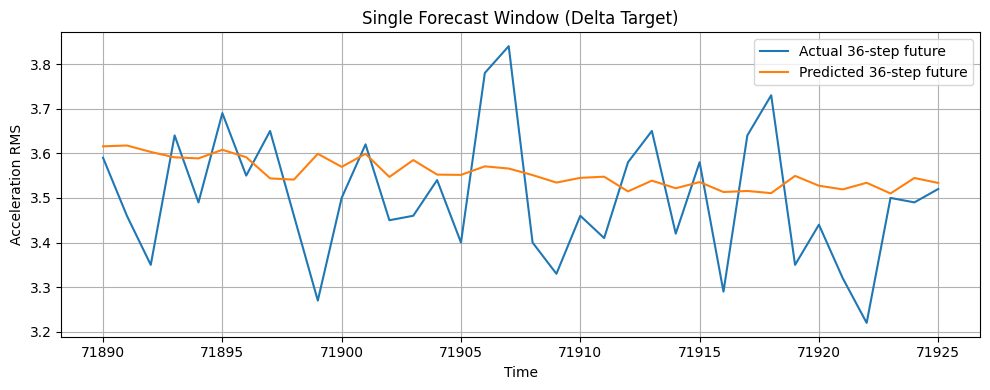

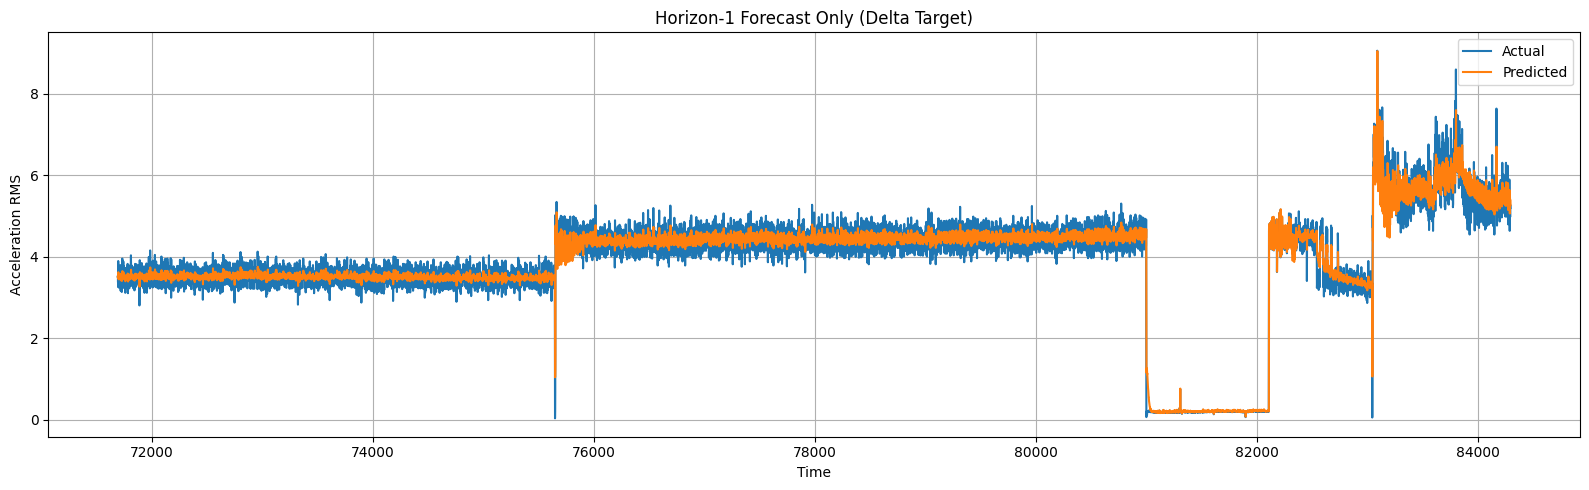

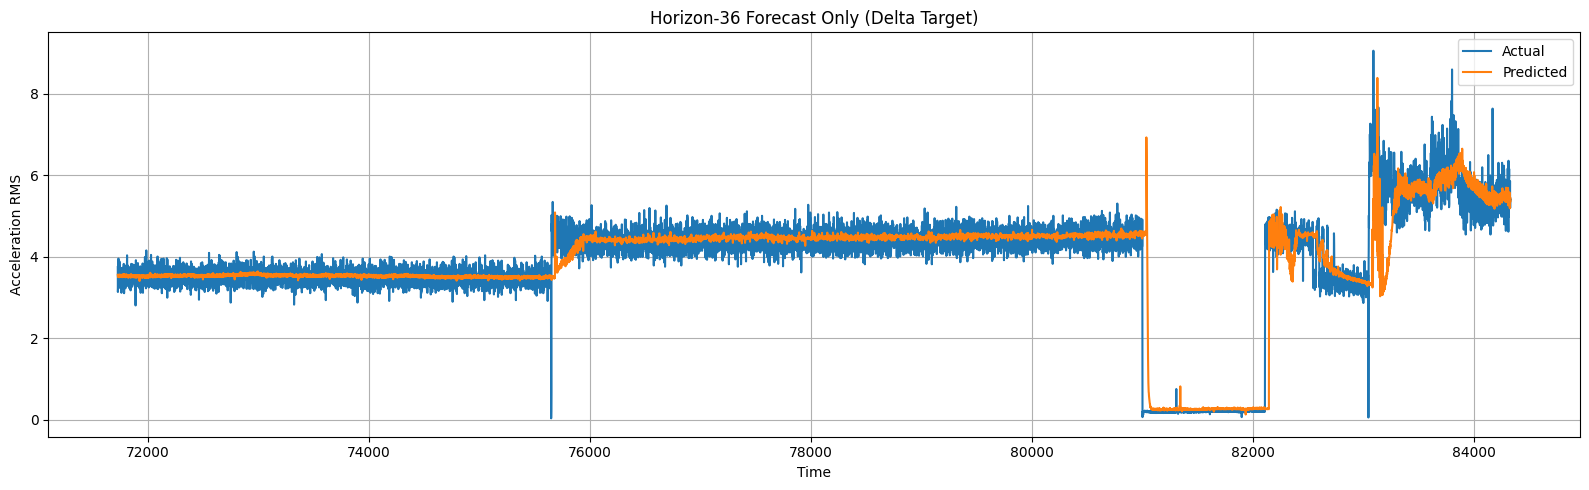


Next 36 forecast values:
[5.4337044 5.4468045 5.4513707 5.4539347 5.4410725 5.447974  5.439971
 5.4422903 5.4432273 5.4660606 5.4574604 5.4629626 5.452856  5.463849
 5.459791  5.453882  5.462576  5.455626  5.454152  5.454191  5.4528937
 5.464613  5.445573  5.4632735 5.454321  5.463248  5.455406  5.4549246
 5.4500427 5.4745913 5.460573  5.4605412 5.4674397 5.456765  5.4741993
 5.4710865]


In [3]:
# 2nd trial
# transformer
# adjust parameters

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =========================================================
# 0. CONFIG
# =========================================================
INPUT_LEN = 256
PRED_LEN = 36

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 64
NUM_EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-5

D_MODEL = 32
NHEAD = 4
NUM_LAYERS = 2
DIM_FEEDFORWARD = 256
DROPOUT = 0.1

MODEL_SAVE_PATH = "transformer_delta_huber_1024_to_36_best_2nd_trial.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# =========================================================
# 1. LOAD SERIES
#    df must already exist
# =========================================================
series = df["Acceleration RMS"].to_numpy(dtype=np.float32)
print("Raw series length:", len(series))


# =========================================================
# 2. GLOBAL NORMALIZATION
#    compute from raw train portion only
# =========================================================
train_series_end = int(len(series) * TRAIN_RATIO)
train_mean = series[:train_series_end].mean()
train_std = series[:train_series_end].std() + 1e-8

series_norm = (series - train_mean) / train_std

print("train_mean:", train_mean)
print("train_std :", train_std)


# =========================================================
# 3. DATASET
#    X        : normalized input window
#    y_delta  : normalized future - last_input_value
#
#    X shape  : (N, 1, INPUT_LEN)
#    y shape  : (N, PRED_LEN)
# =========================================================
class MultiStepDeltaDataset(Dataset):
    def __init__(self, series_norm, input_len=1024, pred_len=36):
        series_norm = np.asarray(series_norm, dtype=np.float32)

        self.input_len = input_len
        self.pred_len = pred_len
        self.n_samples = len(series_norm) - input_len - pred_len + 1

        if self.n_samples <= 0:
            raise ValueError("Series too short for given input_len and pred_len.")

        X = np.array(
            [series_norm[i:i + input_len] for i in range(self.n_samples)],
            dtype=np.float32
        )[:, np.newaxis, :]  # (N, 1, input_len)

        future = np.array(
            [series_norm[i + input_len:i + input_len + pred_len] for i in range(self.n_samples)],
            dtype=np.float32
        )  # (N, pred_len)

        last_val = X[:, 0, -1][:, None]   # (N, 1)
        y_delta = future - last_val       # (N, pred_len)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y_delta, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = MultiStepDeltaDataset(series_norm, input_len=INPUT_LEN, pred_len=PRED_LEN)

print("Total samples:", len(dataset))
print("Sample X shape:", dataset[0][0].shape)   # torch.Size([1, 1024])
print("Sample y shape:", dataset[0][1].shape)   # torch.Size([36])


# =========================================================
# 4. CHRONOLOGICAL SPLIT
# =========================================================
n = len(dataset)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_dataset = Subset(dataset, range(0, train_end))
val_dataset = Subset(dataset, range(train_end, val_end))
test_dataset = Subset(dataset, range(val_end, n))

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))


# =========================================================
# 5. DATALOADERS
# =========================================================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# =========================================================
# 6. MODEL
# =========================================================
class TransformerForecastDelta36(nn.Module):
    def __init__(
        self,
        seq_len=1024,
        input_dim=1,
        pred_len=36,
        d_model=64,
        nhead=8,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len)
        )

    def forward(self, x):
        # x: (B, 1, INPUT_LEN)
        x = x.permute(0, 2, 1)              # (B, INPUT_LEN, 1)
        x = self.input_proj(x)              # (B, INPUT_LEN, d_model)
        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.encoder(x)                 # (B, INPUT_LEN, d_model)
        x = self.norm(x)
        x = x[:, -1, :]                     # (B, d_model)
        out = self.head(x)                  # (B, PRED_LEN), predicted delta
        return out


model = TransformerForecastDelta36(
    seq_len=INPUT_LEN,
    input_dim=1,
    pred_len=PRED_LEN,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
).to(DEVICE)


# =========================================================
# 7. LOSS
#    weighted Huber loss
#    earlier horizons get higher weight
# =========================================================
class WeightedHuberLoss(nn.Module):
    def __init__(self, pred_len, delta=1.0):
        super().__init__()
        self.delta = delta
        w = torch.linspace(1.0, 0.3, pred_len, dtype=torch.float32)
        self.register_buffer("w", w / w.mean())

    def forward(self, pred, target):
        w = self.w.to(pred.device)

        err = pred - target
        abs_err = err.abs()
        huber = torch.where(
            abs_err < self.delta,
            0.5 * err ** 2,
            self.delta * (abs_err - 0.5 * self.delta)
        )
        return (huber * w).mean()


criterion = WeightedHuberLoss(pred_len=PRED_LEN, delta=1.0).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(model)


# =========================================================
# 8. TRAIN / VAL LOOP
# =========================================================
def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_count = 0

    with torch.set_grad_enabled(training):
        for x, y_delta in loader:
            x = x.to(device)             # (B, 1, INPUT_LEN)
            y_delta = y_delta.to(device) # (B, PRED_LEN)

            pred_delta = model(x)        # (B, PRED_LEN)
            loss = criterion(pred_delta, y_delta)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count


best_val_loss = float("inf")
best_state = None

for epoch in range(NUM_EPOCHS):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=DEVICE)

    print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
model.to(DEVICE)
model.eval()

print("Best val loss:", best_val_loss)


# =========================================================
# 9. SAVE CHECKPOINT
# =========================================================
checkpoint = {
    "model_state_dict": model.state_dict(),
    "best_val_loss": best_val_loss,
    "train_mean": float(train_mean),
    "train_std": float(train_std),
    "input_len": INPUT_LEN,
    "pred_len": PRED_LEN,
    "model_config": {
        "seq_len": INPUT_LEN,
        "input_dim": 1,
        "pred_len": PRED_LEN,
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "dim_feedforward": DIM_FEEDFORWARD,
        "dropout": DROPOUT,
    }
}
torch.save(checkpoint, MODEL_SAVE_PATH)
print("Saved best model to:", MODEL_SAVE_PATH)


# =========================================================
# 10. COLLECT TEST PREDICTIONS
#
# model outputs delta
# convert:
#   pred_abs_norm = pred_delta + last_val
#   true_abs_norm = y_delta + last_val
# =========================================================
all_preds_abs_norm = []
all_targets_abs_norm = []

model.eval()
with torch.no_grad():
    for x, y_delta in test_loader:
        x = x.to(DEVICE)
        y_delta = y_delta.to(DEVICE)

        pred_delta = model(x)                       # (B, PRED_LEN)
        last_val = x[:, 0, -1].unsqueeze(1)         # (B, 1)

        pred_abs_norm = pred_delta + last_val       # (B, PRED_LEN)
        true_abs_norm = y_delta + last_val          # (B, PRED_LEN)

        all_preds_abs_norm.append(pred_abs_norm.cpu().numpy())
        all_targets_abs_norm.append(true_abs_norm.cpu().numpy())

all_preds_abs_norm = np.concatenate(all_preds_abs_norm, axis=0)
all_targets_abs_norm = np.concatenate(all_targets_abs_norm, axis=0)

all_preds_raw = all_preds_abs_norm * train_std + train_mean
all_targets_raw = all_targets_abs_norm * train_std + train_mean

print("all_preds_raw shape  :", all_preds_raw.shape)
print("all_targets_raw shape:", all_targets_raw.shape)


# =========================================================
# 11. FLATTENED TEST METRICS
# =========================================================
mse = mean_squared_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
r2 = r2_score(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))

print(f"Test MSE : {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE : {mae:.6f}")
print(f"Test R2  : {r2:.6f}")


# =========================================================
# 12. RMSE BY HORIZON
# =========================================================
print("\nRMSE by selected horizons:")
for h in [0, 5, 11, 35]:
    rmse_h = np.sqrt(mean_squared_error(all_targets_raw[:, h], all_preds_raw[:, h]))
    print(f"Horizon {h+1:02d} RMSE: {rmse_h:.6f}")


# =========================================================
# 13. PERSISTENCE BASELINE
#     predict next 36 points = last observed value
# =========================================================
baseline_preds_abs_norm = []
baseline_targets_abs_norm = []

for x, y_delta in test_loader:
    x_np = x.numpy()
    y_delta_np = y_delta.numpy()

    last_val = x_np[:, 0, -1][:, None]                   # (B, 1)
    pred_abs_norm = np.repeat(last_val, PRED_LEN, axis=1)
    true_abs_norm = y_delta_np + last_val

    baseline_preds_abs_norm.append(pred_abs_norm)
    baseline_targets_abs_norm.append(true_abs_norm)

baseline_preds_abs_norm = np.concatenate(baseline_preds_abs_norm, axis=0)
baseline_targets_abs_norm = np.concatenate(baseline_targets_abs_norm, axis=0)

baseline_preds_raw = baseline_preds_abs_norm * train_std + train_mean
baseline_targets_raw = baseline_targets_abs_norm * train_std + train_mean

baseline_rmse = np.sqrt(mean_squared_error(
    baseline_targets_raw.reshape(-1),
    baseline_preds_raw.reshape(-1)
))
print("\nPersistence baseline RMSE:", baseline_rmse)


# =========================================================
# 14. SINGLE FORECAST WINDOW
# =========================================================
idx = 200  # change if needed

x, y_delta = test_dataset[idx]
x_in = x.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_delta = model(x_in).cpu().numpy()[0]

x_np = x.numpy()
y_delta_np = y_delta.numpy()

last_val = x_np[0, -1]
pred_abs_norm = pred_delta + last_val
true_abs_norm = y_delta_np + last_val

pred_raw = pred_abs_norm * train_std + train_mean
true_raw = true_abs_norm * train_std + train_mean

t0 = val_end + idx + INPUT_LEN
t_axis = np.arange(t0, t0 + PRED_LEN)

plt.figure(figsize=(10, 4))
plt.plot(t_axis, true_raw, label="Actual 36-step future")
plt.plot(t_axis, pred_raw, label="Predicted 36-step future")
plt.title("Single Forecast Window (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 15. HORIZON-1 PLOT
# =========================================================
h = 0

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h1 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h1, h_true, label="Actual")
plt.plot(t_axis_h1, h_pred, label="Predicted")
plt.title("Horizon-1 Forecast Only (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 16. OPTIONAL: HORIZON-36 PLOT
# =========================================================
h = 35

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h36 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h36, h_true, label="Actual")
plt.plot(t_axis_h36, h_pred, label="Predicted")
plt.title("Horizon-36 Forecast Only (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 17. OPTIONAL: NEXT 36 FORECAST FROM LATEST WINDOW
# =========================================================
last_window_norm = series_norm[-INPUT_LEN:]
last_window_tensor = torch.tensor(last_window_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    next_delta_norm = model(last_window_tensor).cpu().numpy()[0]

last_val = last_window_norm[-1]
next_abs_norm = next_delta_norm + last_val
next_abs_raw = next_abs_norm * train_std + train_mean

print("\nNext 36 forecast values:")
print(next_abs_raw)

Using device: cuda
Raw series length: 84332
train_mean: 4.396669
train_std : 3.2276935677392578
Total samples: 83273
Sample X shape: torch.Size([1, 1024])
Sample y shape: torch.Size([36])
Train samples: 58291
Val samples  : 12491
Test samples : 12491
LSTMForecastDelta36(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.1)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=36, bias=True)
  )
)
Epoch 001 | train_loss=0.013276 | val_loss=0.002599
Epoch 002 | train_loss=0.013230 | val_loss=0.002603
Epoch 003 | train_loss=0.013227 | val_loss=0.002596
Epoch 004 | train_loss=0.013226 | val_loss=0.002598
Epoch 005 | train_loss=0.013226 | val_loss=0.002592
Epoch 006 | train_loss=0.013226 | val_loss=0.002594
Epoch 007 | train_loss=0.013227 | val_loss=0.002599
Epoch 008 | train_loss=0.013226 | val_loss=0.002594
Epoch 009 | train_loss=0.013225 | val_loss

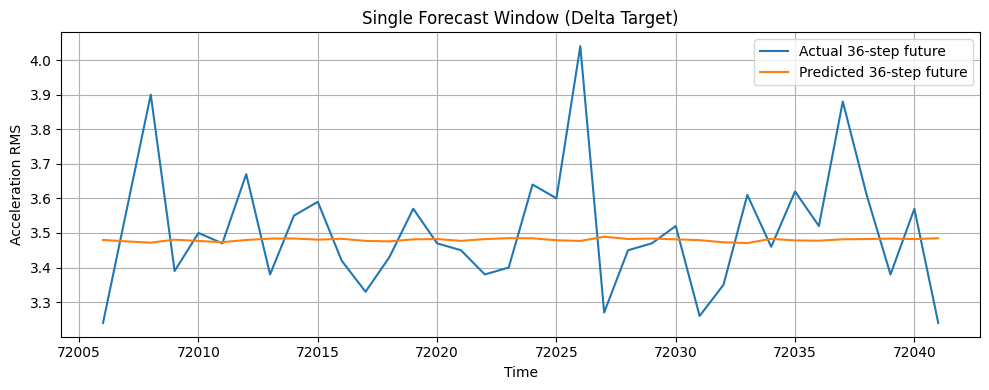

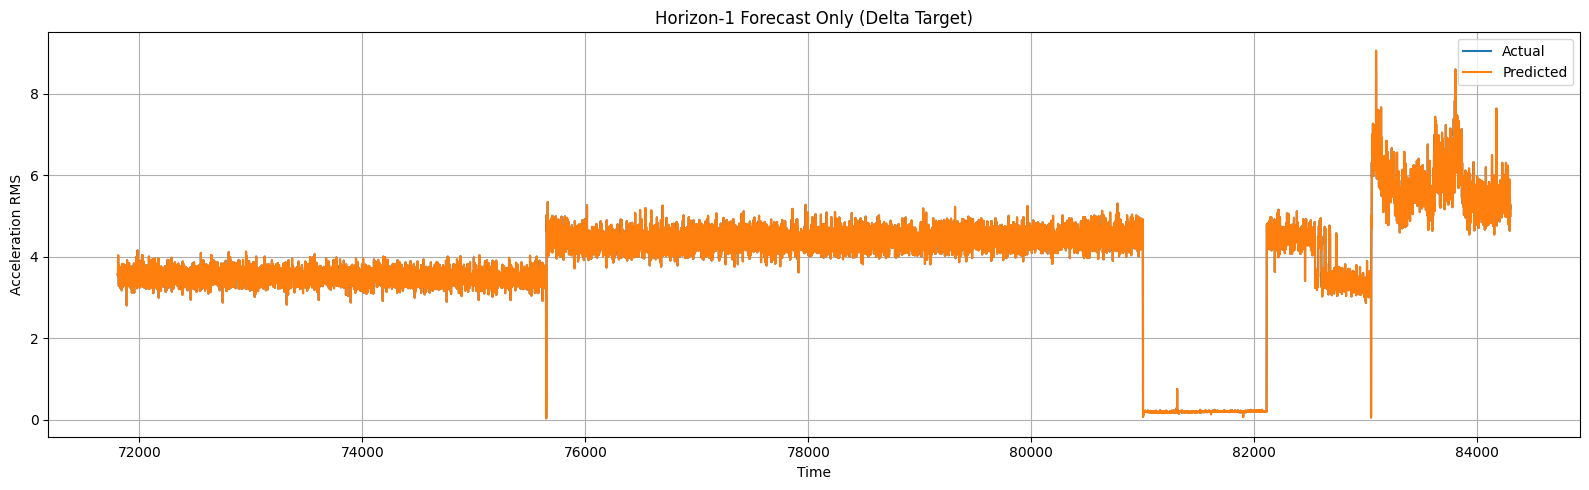

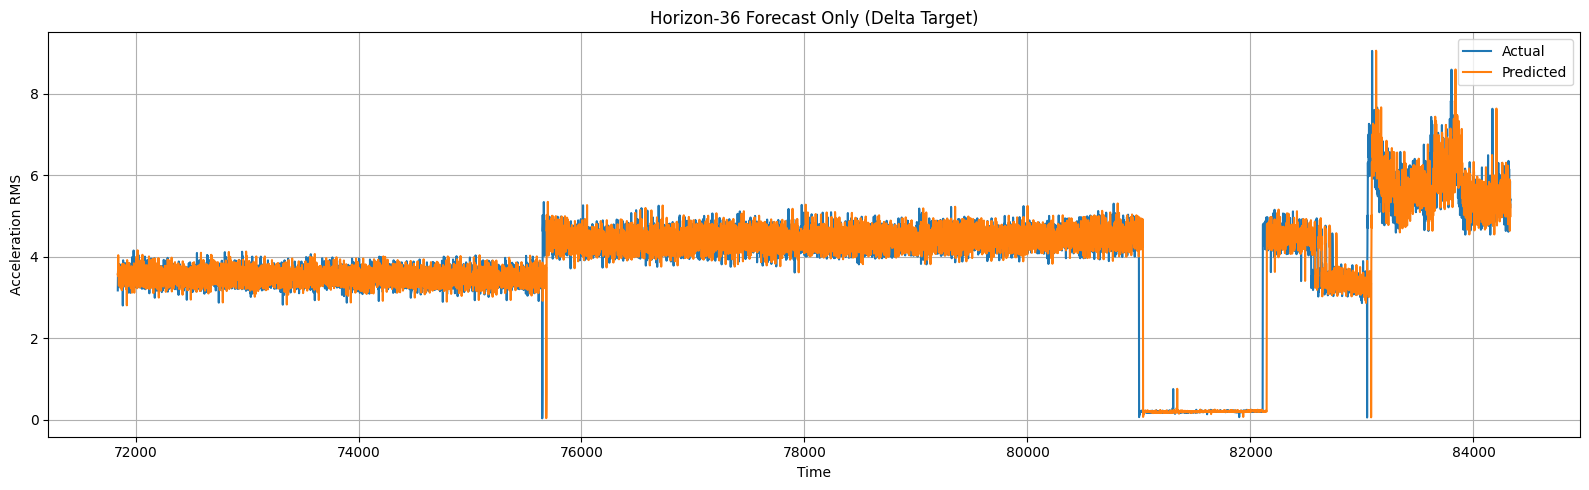


Next 36 forecast values:
[5.3997154 5.395507  5.3919525 5.4006677 5.3967586 5.39335   5.399711
 5.4035993 5.404031  5.400615  5.40314   5.397104  5.3955774 5.401495
 5.4023547 5.397107  5.402299  5.4048786 5.404544  5.398854  5.396919
 5.4090443 5.402599  5.403691  5.4015822 5.3991823 5.392957  5.390711
 5.4031005 5.398326  5.3976846 5.4016476 5.4023685 5.403633  5.4023275
 5.4046707]


In [4]:
# trial 3
# LSTM

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =========================================================
# 0. CONFIG
# =========================================================
INPUT_LEN = 1024
PRED_LEN = 36

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 64
NUM_EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-5

D_MODEL = 64
NHEAD = 8
NUM_LAYERS = 3
DIM_FEEDFORWARD = 256
DROPOUT = 0.1

MODEL_SAVE_PATH = "transformer_delta_huber_1024_to_36_best.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# =========================================================
# 1. LOAD SERIES
#    df must already exist
# =========================================================
series = df["Acceleration RMS"].to_numpy(dtype=np.float32)
print("Raw series length:", len(series))


# =========================================================
# 2. GLOBAL NORMALIZATION
#    compute from raw train portion only
# =========================================================
train_series_end = int(len(series) * TRAIN_RATIO)
train_mean = series[:train_series_end].mean()
train_std = series[:train_series_end].std() + 1e-8

series_norm = (series - train_mean) / train_std

print("train_mean:", train_mean)
print("train_std :", train_std)


# =========================================================
# 3. DATASET
#    X        : normalized input window
#    y_delta  : normalized future - last_input_value
#
#    X shape  : (N, 1, INPUT_LEN)
#    y shape  : (N, PRED_LEN)
# =========================================================
class MultiStepDeltaDataset(Dataset):
    def __init__(self, series_norm, input_len=1024, pred_len=36):
        series_norm = np.asarray(series_norm, dtype=np.float32)

        self.input_len = input_len
        self.pred_len = pred_len
        self.n_samples = len(series_norm) - input_len - pred_len + 1

        if self.n_samples <= 0:
            raise ValueError("Series too short for given input_len and pred_len.")

        X = np.array(
            [series_norm[i:i + input_len] for i in range(self.n_samples)],
            dtype=np.float32
        )[:, np.newaxis, :]  # (N, 1, input_len)

        future = np.array(
            [series_norm[i + input_len:i + input_len + pred_len] for i in range(self.n_samples)],
            dtype=np.float32
        )  # (N, pred_len)

        last_val = X[:, 0, -1][:, None]   # (N, 1)
        y_delta = future - last_val       # (N, pred_len)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y_delta, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = MultiStepDeltaDataset(series_norm, input_len=INPUT_LEN, pred_len=PRED_LEN)

print("Total samples:", len(dataset))
print("Sample X shape:", dataset[0][0].shape)   # torch.Size([1, 1024])
print("Sample y shape:", dataset[0][1].shape)   # torch.Size([36])


# =========================================================
# 4. CHRONOLOGICAL SPLIT
# =========================================================
n = len(dataset)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_dataset = Subset(dataset, range(0, train_end))
val_dataset = Subset(dataset, range(train_end, val_end))
test_dataset = Subset(dataset, range(val_end, n))

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))


# =========================================================
# 5. DATALOADERS
# =========================================================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# =========================================================
# 6. MODEL
# =========================================================

class LSTMForecastDelta36(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_size=64,
        num_layers=2,
        pred_len=36,
        dropout=0.1
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, pred_len)
        )

    def forward(self, x):
        # x: (B, 1, INPUT_LEN)
        x = x.permute(0, 2, 1)          # (B, INPUT_LEN, 1)

        out, (h_n, c_n) = self.lstm(x)

        # take last layer hidden state
        h_last = h_n[-1]                # (B, hidden_size)

        pred_delta = self.head(h_last)  # (B, PRED_LEN)
        return pred_delta


model = LSTMForecastDelta36(
    input_dim=1,
    hidden_size=64,
    num_layers=2,
    pred_len=PRED_LEN,
    dropout=0.1
).to(DEVICE)


# =========================================================
# 7. LOSS
#    weighted Huber loss
#    earlier horizons get higher weight
# =========================================================
class WeightedHuberLoss(nn.Module):
    def __init__(self, pred_len, delta=1.0):
        super().__init__()
        self.delta = delta
        w = torch.linspace(1.0, 0.3, pred_len, dtype=torch.float32)
        self.register_buffer("w", w / w.mean())

    def forward(self, pred, target):
        w = self.w.to(pred.device)

        err = pred - target
        abs_err = err.abs()
        huber = torch.where(
            abs_err < self.delta,
            0.5 * err ** 2,
            self.delta * (abs_err - 0.5 * self.delta)
        )
        return (huber * w).mean()


criterion = WeightedHuberLoss(pred_len=PRED_LEN, delta=1.0).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(model)


# =========================================================
# 8. TRAIN / VAL LOOP
# =========================================================
def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_count = 0

    with torch.set_grad_enabled(training):
        for x, y_delta in loader:
            x = x.to(device)             # (B, 1, INPUT_LEN)
            y_delta = y_delta.to(device) # (B, PRED_LEN)

            pred_delta = model(x)        # (B, PRED_LEN)
            loss = criterion(pred_delta, y_delta)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count


best_val_loss = float("inf")
best_state = None

for epoch in range(NUM_EPOCHS):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=DEVICE)

    print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
model.to(DEVICE)
model.eval()

print("Best val loss:", best_val_loss)


# =========================================================
# 9. SAVE CHECKPOINT
# =========================================================
checkpoint = {
    "model_state_dict": model.state_dict(),
    "best_val_loss": best_val_loss,
    "train_mean": float(train_mean),
    "train_std": float(train_std),
    "input_len": INPUT_LEN,
    "pred_len": PRED_LEN,
    "model_config": {
        "seq_len": INPUT_LEN,
        "input_dim": 1,
        "pred_len": PRED_LEN,
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "dim_feedforward": DIM_FEEDFORWARD,
        "dropout": DROPOUT,
    }
}
torch.save(checkpoint, MODEL_SAVE_PATH)
print("Saved best model to:", MODEL_SAVE_PATH)


# =========================================================
# 10. COLLECT TEST PREDICTIONS
#
# model outputs delta
# convert:
#   pred_abs_norm = pred_delta + last_val
#   true_abs_norm = y_delta + last_val
# =========================================================
all_preds_abs_norm = []
all_targets_abs_norm = []

model.eval()
with torch.no_grad():
    for x, y_delta in test_loader:
        x = x.to(DEVICE)
        y_delta = y_delta.to(DEVICE)

        pred_delta = model(x)                       # (B, PRED_LEN)
        last_val = x[:, 0, -1].unsqueeze(1)         # (B, 1)

        pred_abs_norm = pred_delta + last_val       # (B, PRED_LEN)
        true_abs_norm = y_delta + last_val          # (B, PRED_LEN)

        all_preds_abs_norm.append(pred_abs_norm.cpu().numpy())
        all_targets_abs_norm.append(true_abs_norm.cpu().numpy())

all_preds_abs_norm = np.concatenate(all_preds_abs_norm, axis=0)
all_targets_abs_norm = np.concatenate(all_targets_abs_norm, axis=0)

all_preds_raw = all_preds_abs_norm * train_std + train_mean
all_targets_raw = all_targets_abs_norm * train_std + train_mean

print("all_preds_raw shape  :", all_preds_raw.shape)
print("all_targets_raw shape:", all_targets_raw.shape)


# =========================================================
# 11. FLATTENED TEST METRICS
# =========================================================
mse = mean_squared_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
r2 = r2_score(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))

print(f"Test MSE : {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE : {mae:.6f}")
print(f"Test R2  : {r2:.6f}")


# =========================================================
# 12. RMSE BY HORIZON
# =========================================================
print("\nRMSE by selected horizons:")
for h in [0, 5, 11, 35]:
    rmse_h = np.sqrt(mean_squared_error(all_targets_raw[:, h], all_preds_raw[:, h]))
    print(f"Horizon {h+1:02d} RMSE: {rmse_h:.6f}")


# =========================================================
# 13. PERSISTENCE BASELINE
#     predict next 36 points = last observed value
# =========================================================
baseline_preds_abs_norm = []
baseline_targets_abs_norm = []

for x, y_delta in test_loader:
    x_np = x.numpy()
    y_delta_np = y_delta.numpy()

    last_val = x_np[:, 0, -1][:, None]                   # (B, 1)
    pred_abs_norm = np.repeat(last_val, PRED_LEN, axis=1)
    true_abs_norm = y_delta_np + last_val

    baseline_preds_abs_norm.append(pred_abs_norm)
    baseline_targets_abs_norm.append(true_abs_norm)

baseline_preds_abs_norm = np.concatenate(baseline_preds_abs_norm, axis=0)
baseline_targets_abs_norm = np.concatenate(baseline_targets_abs_norm, axis=0)

baseline_preds_raw = baseline_preds_abs_norm * train_std + train_mean
baseline_targets_raw = baseline_targets_abs_norm * train_std + train_mean

baseline_rmse = np.sqrt(mean_squared_error(
    baseline_targets_raw.reshape(-1),
    baseline_preds_raw.reshape(-1)
))
print("\nPersistence baseline RMSE:", baseline_rmse)


# =========================================================
# 14. SINGLE FORECAST WINDOW
# =========================================================
idx = 200  # change if needed

x, y_delta = test_dataset[idx]
x_in = x.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_delta = model(x_in).cpu().numpy()[0]

x_np = x.numpy()
y_delta_np = y_delta.numpy()

last_val = x_np[0, -1]
pred_abs_norm = pred_delta + last_val
true_abs_norm = y_delta_np + last_val

pred_raw = pred_abs_norm * train_std + train_mean
true_raw = true_abs_norm * train_std + train_mean

t0 = val_end + idx + INPUT_LEN
t_axis = np.arange(t0, t0 + PRED_LEN)

plt.figure(figsize=(10, 4))
plt.plot(t_axis, true_raw, label="Actual 36-step future")
plt.plot(t_axis, pred_raw, label="Predicted 36-step future")
plt.title("Single Forecast Window (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 15. HORIZON-1 PLOT
# =========================================================
h = 0

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h1 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h1, h_true, label="Actual")
plt.plot(t_axis_h1, h_pred, label="Predicted")
plt.title("Horizon-1 Forecast Only (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 16. OPTIONAL: HORIZON-36 PLOT
# =========================================================
h = 35

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h36 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h36, h_true, label="Actual")
plt.plot(t_axis_h36, h_pred, label="Predicted")
plt.title("Horizon-36 Forecast Only (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 17. OPTIONAL: NEXT 36 FORECAST FROM LATEST WINDOW
# =========================================================
last_window_norm = series_norm[-INPUT_LEN:]
last_window_tensor = torch.tensor(last_window_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    next_delta_norm = model(last_window_tensor).cpu().numpy()[0]

last_val = last_window_norm[-1]
next_abs_norm = next_delta_norm + last_val
next_abs_raw = next_abs_norm * train_std + train_mean

print("\nNext 36 forecast values:")
print(next_abs_raw)

Using device: cuda
Raw series length: 84332
train_mean: 4.396669
train_std : 3.2276935677392578
Total samples: 83273
X sample shape: torch.Size([1, 1024])
y sample shape: torch.Size([36])
Train samples: 58291
Val samples  : 12491
Test samples : 12491
GRUForecastDelta36(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.1)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=36, bias=True)
  )
)
Epoch 001 | train_loss=0.013276 | val_loss=0.002593
Epoch 002 | train_loss=0.013228 | val_loss=0.002610
Epoch 003 | train_loss=0.013225 | val_loss=0.002596
Epoch 004 | train_loss=0.013225 | val_loss=0.002593
Epoch 005 | train_loss=0.013226 | val_loss=0.002592
Epoch 006 | train_loss=0.013226 | val_loss=0.002592
Epoch 007 | train_loss=0.013226 | val_loss=0.002592
Epoch 008 | train_loss=0.013226 | val_loss=0.002597
Epoch 009 | train_loss=0.013227 | val_loss=0.

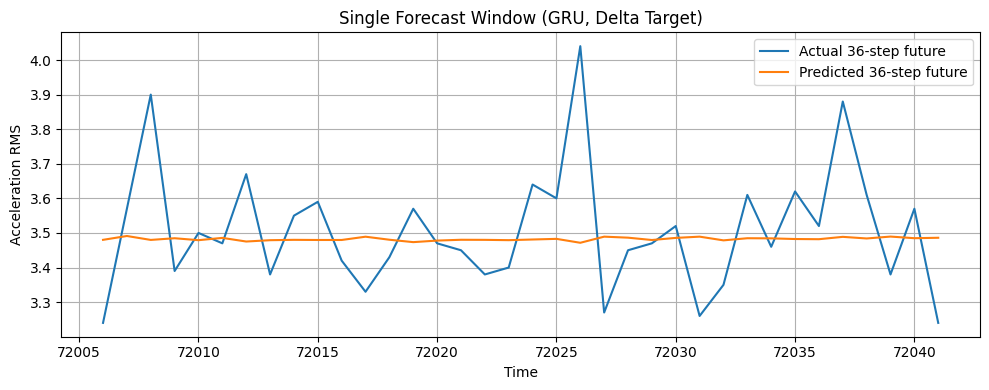

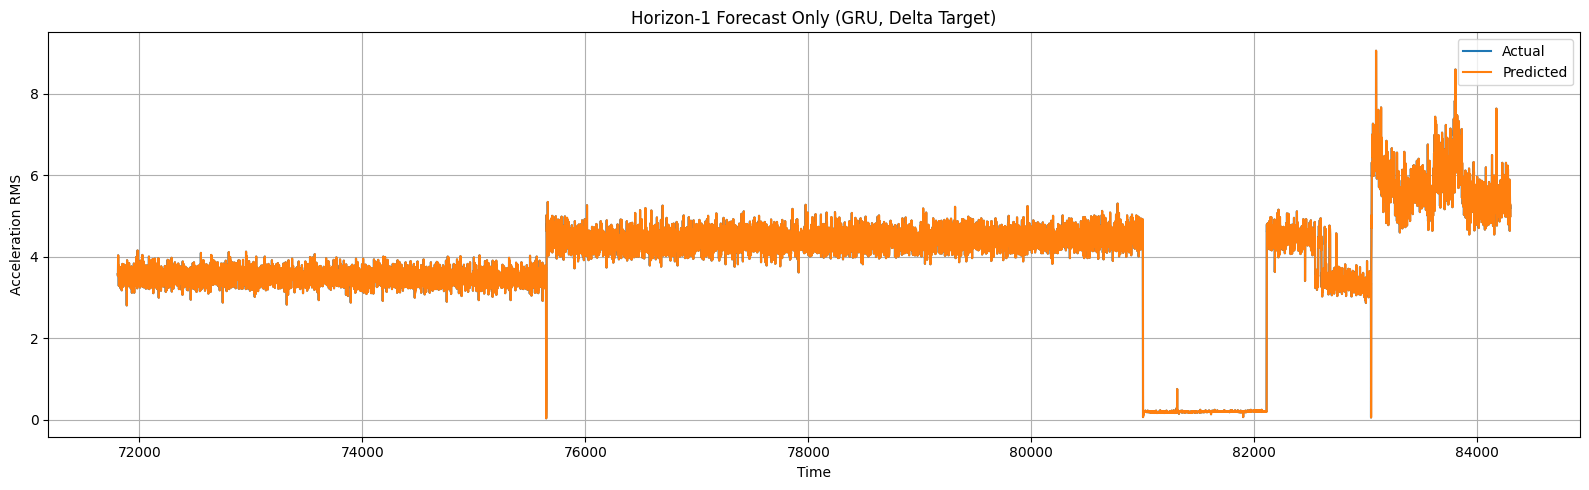

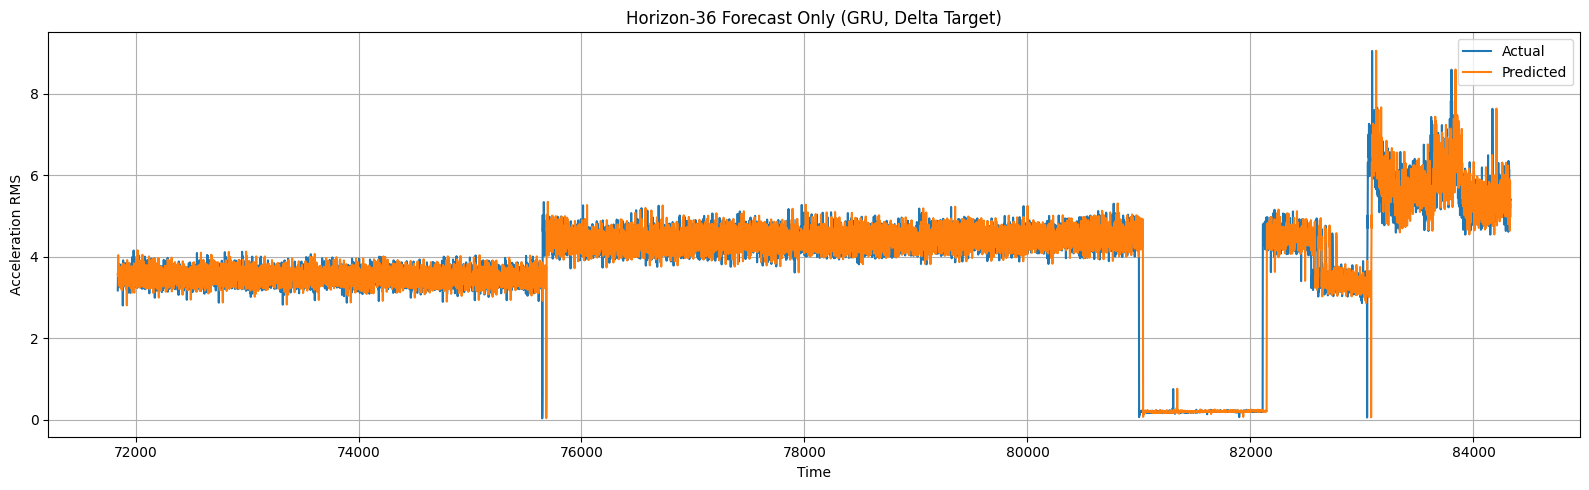


Next 36 forecast values:
[5.400081  5.411208  5.39985   5.404724  5.3990836 5.40574   5.395219
 5.3990536 5.400111  5.399664  5.3996887 5.409169  5.4004097 5.3934603
 5.3979454 5.4002943 5.4000516 5.399153  5.401068  5.402919  5.391578
 5.4092965 5.406368  5.3995934 5.405682  5.409318  5.398579  5.4047456
 5.4043913 5.402454  5.4019284 5.4087367 5.4040656 5.40954   5.4048457
 5.4060965]


In [5]:
# GRU

import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =========================================================
# 0. REPRODUCIBILITY
# =========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# =========================================================
# 1. CONFIG
# =========================================================
INPUT_LEN = 1024
PRED_LEN = 36

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

BATCH_SIZE = 64
NUM_EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-5

HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.1

MODEL_SAVE_PATH = "gru_delta_huber_1024_to_36_best.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# =========================================================
# 2. LOAD SERIES
#    df must already exist
# =========================================================
series = df["Acceleration RMS"].to_numpy(dtype=np.float32)
print("Raw series length:", len(series))


# =========================================================
# 3. NORMALIZATION
#    train stats from raw train portion only
# =========================================================
train_series_end = int(len(series) * TRAIN_RATIO)
train_mean = series[:train_series_end].mean()
train_std = series[:train_series_end].std() + 1e-8

series_norm = (series - train_mean) / train_std

print("train_mean:", train_mean)
print("train_std :", train_std)


# =========================================================
# 4. DATASET
#    X: normalized input
#    y_delta: normalized future - last_input_value
# =========================================================
class MultiStepDeltaDataset(Dataset):
    def __init__(self, series_norm, input_len=1024, pred_len=36):
        series_norm = np.asarray(series_norm, dtype=np.float32)

        self.input_len = input_len
        self.pred_len = pred_len
        self.n_samples = len(series_norm) - input_len - pred_len + 1

        if self.n_samples <= 0:
            raise ValueError("Series too short for given input_len and pred_len.")

        X = np.array(
            [series_norm[i:i + input_len] for i in range(self.n_samples)],
            dtype=np.float32
        )[:, np.newaxis, :]   # (N, 1, input_len)

        future = np.array(
            [series_norm[i + input_len:i + input_len + pred_len] for i in range(self.n_samples)],
            dtype=np.float32
        )   # (N, pred_len)

        last_val = X[:, 0, -1][:, None]   # (N, 1)
        y_delta = future - last_val       # (N, pred_len)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y_delta, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = MultiStepDeltaDataset(series_norm, input_len=INPUT_LEN, pred_len=PRED_LEN)

print("Total samples:", len(dataset))
print("X sample shape:", dataset[0][0].shape)   # torch.Size([1, 1024])
print("y sample shape:", dataset[0][1].shape)   # torch.Size([36])


# =========================================================
# 5. CHRONOLOGICAL SPLIT
# =========================================================
n = len(dataset)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_dataset = Subset(dataset, range(0, train_end))
val_dataset = Subset(dataset, range(train_end, val_end))
test_dataset = Subset(dataset, range(val_end, n))

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))


# =========================================================
# 6. DATALOADERS
# =========================================================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# =========================================================
# 7. MODEL: GRU
# =========================================================
class GRUForecastDelta36(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_size=64,
        num_layers=2,
        pred_len=36,
        dropout=0.1
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, pred_len)
        )

    def forward(self, x):
        # x: (B, 1, INPUT_LEN)
        x = x.permute(0, 2, 1)      # (B, INPUT_LEN, 1)

        out, h_n = self.gru(x)
        h_last = h_n[-1]            # (B, hidden_size)

        pred_delta = self.head(h_last)   # (B, PRED_LEN)
        return pred_delta


model = GRUForecastDelta36(
    input_dim=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    pred_len=PRED_LEN,
    dropout=DROPOUT
).to(DEVICE)

print(model)


# =========================================================
# 8. LOSS
# =========================================================
class WeightedHuberLoss(nn.Module):
    def __init__(self, pred_len, delta=1.0):
        super().__init__()
        self.delta = delta
        w = torch.linspace(1.0, 0.3, pred_len, dtype=torch.float32)
        self.register_buffer("w", w / w.mean())

    def forward(self, pred, target):
        w = self.w.to(pred.device)

        err = pred - target
        abs_err = err.abs()

        huber = torch.where(
            abs_err < self.delta,
            0.5 * err ** 2,
            self.delta * (abs_err - 0.5 * self.delta)
        )
        return (huber * w).mean()


criterion = WeightedHuberLoss(pred_len=PRED_LEN, delta=1.0).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


# =========================================================
# 9. TRAIN / VAL LOOP
# =========================================================
def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_count = 0

    with torch.set_grad_enabled(training):
        for x, y_delta in loader:
            x = x.to(device)
            y_delta = y_delta.to(device)

            pred_delta = model(x)
            loss = criterion(pred_delta, y_delta)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count


best_val_loss = float("inf")
best_state = None

for epoch in range(NUM_EPOCHS):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=DEVICE)

    print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
model.to(DEVICE)
model.eval()

print("Best val loss:", best_val_loss)


# =========================================================
# 10. SAVE CHECKPOINT
# =========================================================
checkpoint = {
    "model_state_dict": model.state_dict(),
    "best_val_loss": best_val_loss,
    "train_mean": float(train_mean),
    "train_std": float(train_std),
    "input_len": INPUT_LEN,
    "pred_len": PRED_LEN,
    "model_type": "GRU",
    "model_config": {
        "input_dim": 1,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "pred_len": PRED_LEN,
        "dropout": DROPOUT,
    }
}
torch.save(checkpoint, MODEL_SAVE_PATH)
print("Saved best model to:", MODEL_SAVE_PATH)


# =========================================================
# 11. COLLECT TEST PREDICTIONS
#     GRU outputs delta, so convert back to absolute values
# =========================================================
all_preds_abs_norm = []
all_targets_abs_norm = []

model.eval()
with torch.no_grad():
    for x, y_delta in test_loader:
        x = x.to(DEVICE)
        y_delta = y_delta.to(DEVICE)

        pred_delta = model(x)                   # (B, PRED_LEN)
        last_val = x[:, 0, -1].unsqueeze(1)     # (B, 1)

        pred_abs_norm = pred_delta + last_val
        true_abs_norm = y_delta + last_val

        all_preds_abs_norm.append(pred_abs_norm.cpu().numpy())
        all_targets_abs_norm.append(true_abs_norm.cpu().numpy())

all_preds_abs_norm = np.concatenate(all_preds_abs_norm, axis=0)
all_targets_abs_norm = np.concatenate(all_targets_abs_norm, axis=0)

all_preds_raw = all_preds_abs_norm * train_std + train_mean
all_targets_raw = all_targets_abs_norm * train_std + train_mean

print("all_preds_raw shape  :", all_preds_raw.shape)
print("all_targets_raw shape:", all_targets_raw.shape)


# =========================================================
# 12. TEST METRICS
# =========================================================
mse = mean_squared_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
r2 = r2_score(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))

print(f"Test MSE : {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE : {mae:.6f}")
print(f"Test R2  : {r2:.6f}")


# =========================================================
# 13. RMSE BY HORIZON
# =========================================================
print("\nRMSE by selected horizons:")
for h in [0, 5, 11, 35]:
    rmse_h = np.sqrt(mean_squared_error(all_targets_raw[:, h], all_preds_raw[:, h]))
    print(f"Horizon {h+1:02d} RMSE: {rmse_h:.6f}")


# =========================================================
# 14. PERSISTENCE BASELINE
# =========================================================
baseline_preds_abs_norm = []
baseline_targets_abs_norm = []

for x, y_delta in test_loader:
    x_np = x.numpy()
    y_delta_np = y_delta.numpy()

    last_val = x_np[:, 0, -1][:, None]
    pred_abs_norm = np.repeat(last_val, PRED_LEN, axis=1)
    true_abs_norm = y_delta_np + last_val

    baseline_preds_abs_norm.append(pred_abs_norm)
    baseline_targets_abs_norm.append(true_abs_norm)

baseline_preds_abs_norm = np.concatenate(baseline_preds_abs_norm, axis=0)
baseline_targets_abs_norm = np.concatenate(baseline_targets_abs_norm, axis=0)

baseline_preds_raw = baseline_preds_abs_norm * train_std + train_mean
baseline_targets_raw = baseline_targets_abs_norm * train_std + train_mean

baseline_rmse = np.sqrt(mean_squared_error(
    baseline_targets_raw.reshape(-1),
    baseline_preds_raw.reshape(-1)
))
print("\nPersistence baseline RMSE:", baseline_rmse)


# =========================================================
# 15. SINGLE FORECAST WINDOW
# =========================================================
idx = 200

x, y_delta = test_dataset[idx]
x_in = x.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_delta = model(x_in).cpu().numpy()[0]

x_np = x.numpy()
y_delta_np = y_delta.numpy()

last_val = x_np[0, -1]
pred_abs_norm = pred_delta + last_val
true_abs_norm = y_delta_np + last_val

pred_raw = pred_abs_norm * train_std + train_mean
true_raw = true_abs_norm * train_std + train_mean

t0 = val_end + idx + INPUT_LEN
t_axis = np.arange(t0, t0 + PRED_LEN)

plt.figure(figsize=(10, 4))
plt.plot(t_axis, true_raw, label="Actual 36-step future")
plt.plot(t_axis, pred_raw, label="Predicted 36-step future")
plt.title("Single Forecast Window (GRU, Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 16. HORIZON-1 PLOT
# =========================================================
h = 0

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h1 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h1, h_true, label="Actual")
plt.plot(t_axis_h1, h_pred, label="Predicted")
plt.title("Horizon-1 Forecast Only (GRU, Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 17. HORIZON-36 PLOT
# =========================================================
h = 35

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h36 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h36, h_true, label="Actual")
plt.plot(t_axis_h36, h_pred, label="Predicted")
plt.title("Horizon-36 Forecast Only (GRU, Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 18. NEXT 36 FORECAST FROM LATEST WINDOW
# =========================================================
last_window_norm = series_norm[-INPUT_LEN:]
last_window_tensor = torch.tensor(last_window_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    next_delta_norm = model(last_window_tensor).cpu().numpy()[0]

last_val = last_window_norm[-1]
next_abs_norm = next_delta_norm + last_val
next_abs_raw = next_abs_norm * train_std + train_mean

print("\nNext 36 forecast values:")
print(next_abs_raw)

Using device: cuda
Raw series length: 84332
train_mean: 4.396669
train_std : 3.2276935677392578
Total samples: 83273
Sample X shape: torch.Size([1, 1024])
Sample y shape: torch.Size([36])
Train samples: 58291
Val samples  : 12491
Test samples : 12491
LSTMForecastDelta36(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.1)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=36, bias=True)
  )
)
Epoch 001 | train_loss=0.218173 | val_loss=0.204453
Epoch 002 | train_loss=0.217798 | val_loss=0.204345
Epoch 003 | train_loss=0.217574 | val_loss=0.204236
Epoch 004 | train_loss=0.217553 | val_loss=0.204240
Epoch 005 | train_loss=0.217415 | val_loss=0.204224
Epoch 006 | train_loss=0.217437 | val_loss=0.204198
Epoch 007 | train_loss=0.217385 | val_loss=0.204206
Epoch 008 | train_loss=0.217407 | val_loss=0.204215
Epoch 009 | train_loss=0.217397 | val_

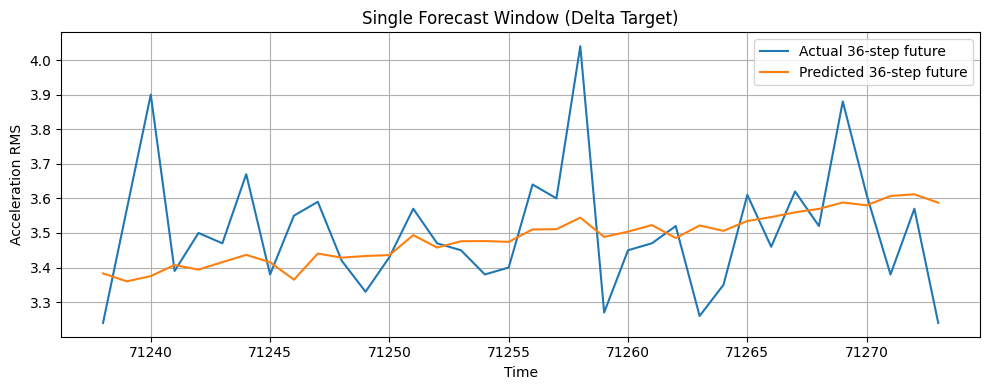

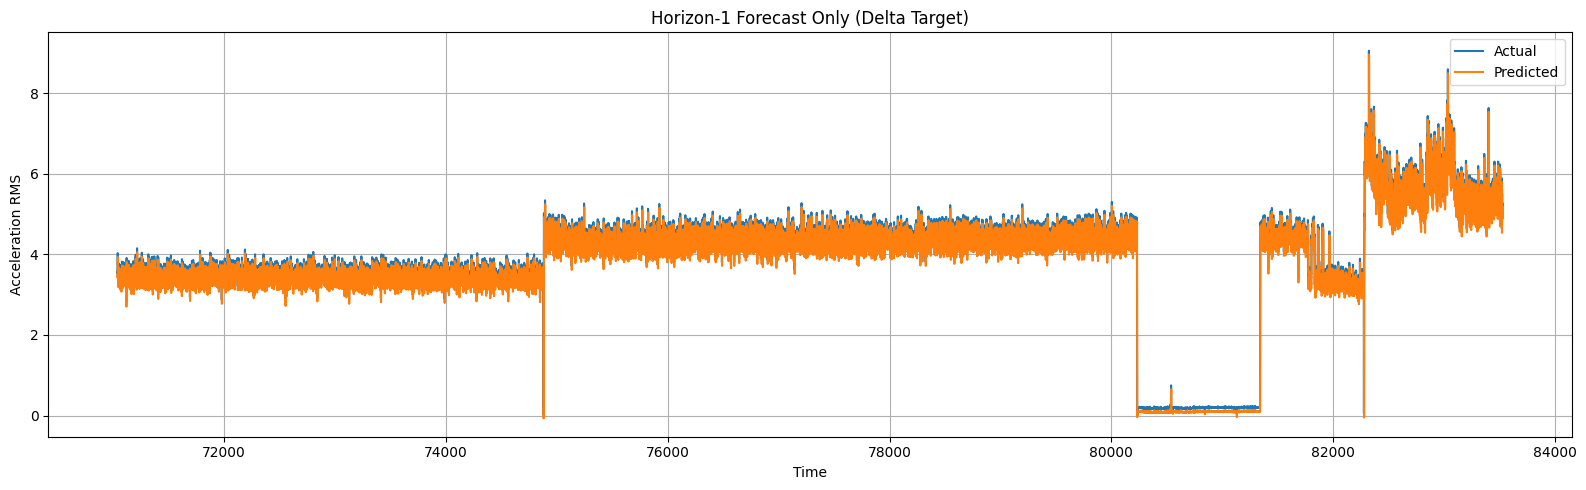

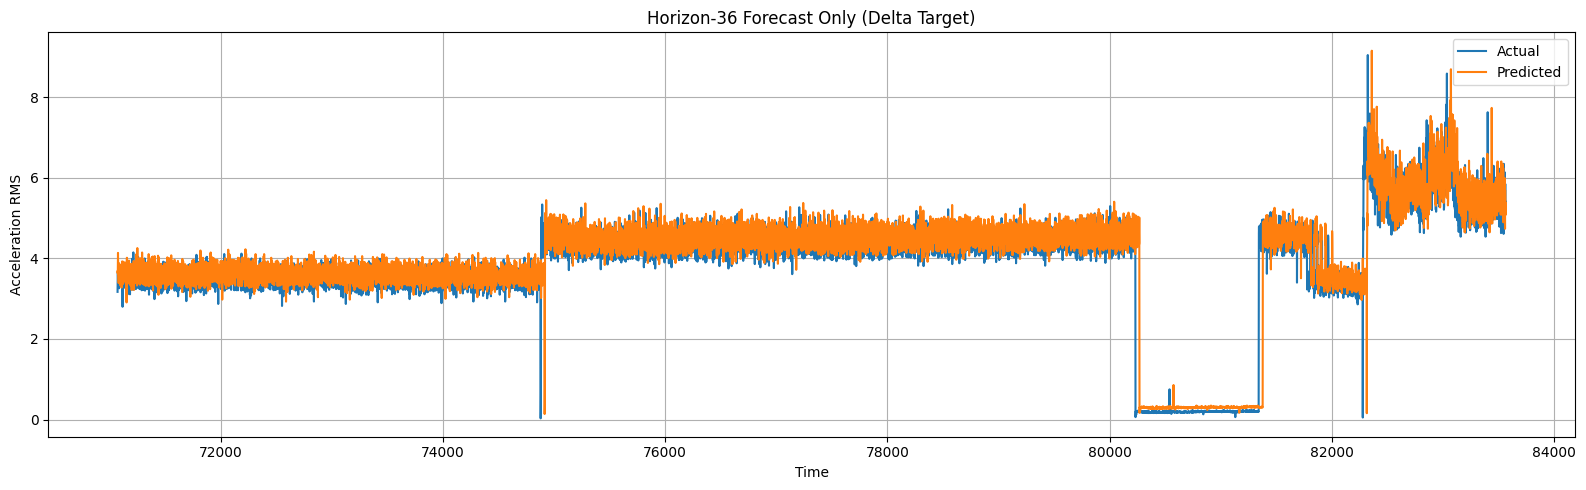


Next 36 forecast values:
[5.3029695 5.2801476 5.295355  5.327244  5.313959  5.335723  5.3565664
 5.33527   5.2850075 5.360375  5.348729  5.353341  5.3559623 5.4136677
 5.377848  5.395946  5.396506  5.394231  5.4301844 5.430814  5.4643235
 5.40851   5.423825  5.442752  5.4053316 5.4414697 5.4260926 5.4545603
 5.4658766 5.4796405 5.4895525 5.508047  5.5000505 5.5268803 5.531704
 5.5074706]


In [6]:
# trial 5
# LSTM

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =========================================================
# 0. CONFIG
# =========================================================
INPUT_LEN = 256
PRED_LEN = 36

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 64
NUM_EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-5

D_MODEL = 64
NHEAD = 8
NUM_LAYERS = 2
DIM_FEEDFORWARD = 256
DROPOUT = 0.1

MODEL_SAVE_PATH = "transformer_delta_huber_1024_to_36_best.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# =========================================================
# 1. LOAD SERIES
#    df must already exist
# =========================================================
series = df["Acceleration RMS"].to_numpy(dtype=np.float32)
print("Raw series length:", len(series))


# =========================================================
# 2. GLOBAL NORMALIZATION
#    compute from raw train portion only
# =========================================================
train_series_end = int(len(series) * TRAIN_RATIO)
train_mean = series[:train_series_end].mean()
train_std = series[:train_series_end].std() + 1e-8

series_norm = (series - train_mean) / train_std

print("train_mean:", train_mean)
print("train_std :", train_std)


# =========================================================
# 3. DATASET
#    X        : normalized input window
#    y_delta  : normalized future - last_input_value
#
#    X shape  : (N, 1, INPUT_LEN)
#    y shape  : (N, PRED_LEN)
# =========================================================
class MultiStepDeltaDataset(Dataset):
    def __init__(self, series_norm, input_len=1024, pred_len=36):
        series_norm = np.asarray(series_norm, dtype=np.float32)

        self.input_len = input_len
        self.pred_len = pred_len
        self.n_samples = len(series_norm) - input_len - pred_len + 1

        if self.n_samples <= 0:
            raise ValueError("Series too short for given input_len and pred_len.")

        X = np.array(
            [series_norm[i:i + input_len] for i in range(self.n_samples)],
            dtype=np.float32
        )[:, np.newaxis, :]  # (N, 1, input_len)

        future = np.array(
            [series_norm[i + input_len:i + input_len + pred_len] for i in range(self.n_samples)],
            dtype=np.float32
        )  # (N, pred_len)

        last_val = X[:, 0, -1][:, None]   # (N, 1)
        y_delta = future - last_val       # (N, pred_len)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y_delta, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class PointTrendLoss(nn.Module):
    def __init__(self, point_w=1.0, diff_w=0.3, corr_w=0.1, delta=1.0):
        super().__init__()
        self.point_w = point_w
        self.diff_w = diff_w
        self.corr_w = corr_w
        self.huber = nn.HuberLoss(delta=delta)

    def forward(self, pred, target):
        # 1) point accuracy
        point_loss = self.huber(pred, target)

        # 2) trend / shape via first differences
        pred_diff = pred[:, 1:] - pred[:, :-1]
        target_diff = target[:, 1:] - target[:, :-1]
        diff_loss = self.huber(pred_diff, target_diff)

        # 3) correlation / shape alignment
        pred_c = pred - pred.mean(dim=1, keepdim=True)
        target_c = target - target.mean(dim=1, keepdim=True)

        numerator = (pred_c * target_c).sum(dim=1)
        denominator = torch.sqrt((pred_c ** 2).sum(dim=1) * (target_c ** 2).sum(dim=1) + 1e-8)
        corr = numerator / (denominator + 1e-8)
        corr_loss = 1.0 - corr.mean()

        return self.point_w * point_loss + self.diff_w * diff_loss + self.corr_w * corr_loss

    dataset = MultiStepDeltaDataset(series_norm, input_len=INPUT_LEN, pred_len=PRED_LEN)

print("Total samples:", len(dataset))
print("Sample X shape:", dataset[0][0].shape)   # torch.Size([1, 1024])
print("Sample y shape:", dataset[0][1].shape)   # torch.Size([36])


# =========================================================
# 4. CHRONOLOGICAL SPLIT
# =========================================================
n = len(dataset)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_dataset = Subset(dataset, range(0, train_end))
val_dataset = Subset(dataset, range(train_end, val_end))
test_dataset = Subset(dataset, range(val_end, n))

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))


# =========================================================
# 5. DATALOADERS
# =========================================================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# =========================================================
# 6. MODEL
# =========================================================

class LSTMForecastDelta36(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_size=64,
        num_layers=2,
        pred_len=36,
        dropout=0.1
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, pred_len)
        )

    def forward(self, x):
        # x: (B, 1, INPUT_LEN)
        x = x.permute(0, 2, 1)          # (B, INPUT_LEN, 1)

        out, (h_n, c_n) = self.lstm(x)

        # take last layer hidden state
        h_last = h_n[-1]                # (B, hidden_size)

        pred_delta = self.head(h_last)  # (B, PRED_LEN)
        return pred_delta


model = LSTMForecastDelta36(
    input_dim=1,
    hidden_size=128,
    num_layers=2,
    pred_len=PRED_LEN,
    dropout=0.1
).to(DEVICE)


# =========================================================
# 7. LOSS
#    weighted Huber loss
#    earlier horizons get higher weight
# =========================================================
class WeightedHuberLoss(nn.Module):
    def __init__(self, pred_len, delta=1.0):
        super().__init__()
        self.delta = delta
        w = torch.linspace(1.0, 0.3, pred_len, dtype=torch.float32)
        self.register_buffer("w", w / w.mean())

    def forward(self, pred, target):
        w = self.w.to(pred.device)

        err = pred - target
        abs_err = err.abs()
        huber = torch.where(
            abs_err < self.delta,
            0.5 * err ** 2,
            self.delta * (abs_err - 0.5 * self.delta)
        )
        return (huber * w).mean()


criterion = PointTrendLoss(point_w=1.0, diff_w=0.5, corr_w=0.2, delta=1.0).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(model)


# =========================================================
# 8. TRAIN / VAL LOOP
# =========================================================
def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_count = 0

    with torch.set_grad_enabled(training):
        for x, y_delta in loader:
            x = x.to(device)             # (B, 1, INPUT_LEN)
            y_delta = y_delta.to(device) # (B, PRED_LEN)

            pred_delta = model(x)                      # (B, PRED_LEN)
            last_val = x[:, 0, -1].unsqueeze(1)        # (B, 1)

            pred_abs = pred_delta + last_val           # reconstructed absolute future
            true_abs = y_delta + last_val

            loss = criterion(pred_abs, true_abs)
            
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count


best_val_loss = float("inf")
best_state = None

for epoch in range(NUM_EPOCHS):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=DEVICE)

    print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
model.to(DEVICE)
model.eval()

print("Best val loss:", best_val_loss)


# =========================================================
# 9. SAVE CHECKPOINT
# =========================================================
checkpoint = {
    "model_state_dict": model.state_dict(),
    "best_val_loss": best_val_loss,
    "train_mean": float(train_mean),
    "train_std": float(train_std),
    "input_len": INPUT_LEN,
    "pred_len": PRED_LEN,
    "model_config": {
        "seq_len": INPUT_LEN,
        "input_dim": 1,
        "pred_len": PRED_LEN,
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "dim_feedforward": DIM_FEEDFORWARD,
        "dropout": DROPOUT,
    }
}
torch.save(checkpoint, MODEL_SAVE_PATH)
print("Saved best model to:", MODEL_SAVE_PATH)


# =========================================================
# 10. COLLECT TEST PREDICTIONS
#
# model outputs delta
# convert:
#   pred_abs_norm = pred_delta + last_val
#   true_abs_norm = y_delta + last_val
# =========================================================
all_preds_abs_norm = []
all_targets_abs_norm = []

model.eval()
with torch.no_grad():
    for x, y_delta in test_loader:
        x = x.to(DEVICE)
        y_delta = y_delta.to(DEVICE)

        pred_delta = model(x)                       # (B, PRED_LEN)
        last_val = x[:, 0, -1].unsqueeze(1)         # (B, 1)

        pred_abs_norm = pred_delta + last_val       # (B, PRED_LEN)
        true_abs_norm = y_delta + last_val          # (B, PRED_LEN)

        all_preds_abs_norm.append(pred_abs_norm.cpu().numpy())
        all_targets_abs_norm.append(true_abs_norm.cpu().numpy())

all_preds_abs_norm = np.concatenate(all_preds_abs_norm, axis=0)
all_targets_abs_norm = np.concatenate(all_targets_abs_norm, axis=0)

all_preds_raw = all_preds_abs_norm * train_std + train_mean
all_targets_raw = all_targets_abs_norm * train_std + train_mean

print("all_preds_raw shape  :", all_preds_raw.shape)
print("all_targets_raw shape:", all_targets_raw.shape)


# =========================================================
# 11. FLATTENED TEST METRICS
# =========================================================
mse = mean_squared_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))
r2 = r2_score(all_targets_raw.reshape(-1), all_preds_raw.reshape(-1))

print(f"Test MSE : {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE : {mae:.6f}")
print(f"Test R2  : {r2:.6f}")


# =========================================================
# 12. RMSE BY HORIZON
# =========================================================
print("\nRMSE by selected horizons:")
for h in [0, 5, 11, 35]:
    rmse_h = np.sqrt(mean_squared_error(all_targets_raw[:, h], all_preds_raw[:, h]))
    print(f"Horizon {h+1:02d} RMSE: {rmse_h:.6f}")


# =========================================================
# 13. PERSISTENCE BASELINE
#     predict next 36 points = last observed value
# =========================================================
baseline_preds_abs_norm = []
baseline_targets_abs_norm = []

for x, y_delta in test_loader:
    x_np = x.numpy()
    y_delta_np = y_delta.numpy()

    last_val = x_np[:, 0, -1][:, None]                   # (B, 1)
    pred_abs_norm = np.repeat(last_val, PRED_LEN, axis=1)
    true_abs_norm = y_delta_np + last_val

    baseline_preds_abs_norm.append(pred_abs_norm)
    baseline_targets_abs_norm.append(true_abs_norm)

baseline_preds_abs_norm = np.concatenate(baseline_preds_abs_norm, axis=0)
baseline_targets_abs_norm = np.concatenate(baseline_targets_abs_norm, axis=0)

baseline_preds_raw = baseline_preds_abs_norm * train_std + train_mean
baseline_targets_raw = baseline_targets_abs_norm * train_std + train_mean

baseline_rmse = np.sqrt(mean_squared_error(
    baseline_targets_raw.reshape(-1),
    baseline_preds_raw.reshape(-1)
))
print("\nPersistence baseline RMSE:", baseline_rmse)


# =========================================================
# 14. SINGLE FORECAST WINDOW
# =========================================================
idx = 200  # change if needed

x, y_delta = test_dataset[idx]
x_in = x.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_delta = model(x_in).cpu().numpy()[0]

x_np = x.numpy()
y_delta_np = y_delta.numpy()

last_val = x_np[0, -1]
pred_abs_norm = pred_delta + last_val
true_abs_norm = y_delta_np + last_val

pred_raw = pred_abs_norm * train_std + train_mean
true_raw = true_abs_norm * train_std + train_mean

t0 = val_end + idx + INPUT_LEN
t_axis = np.arange(t0, t0 + PRED_LEN)

plt.figure(figsize=(10, 4))
plt.plot(t_axis, true_raw, label="Actual 36-step future")
plt.plot(t_axis, pred_raw, label="Predicted 36-step future")
plt.title("Single Forecast Window (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 15. HORIZON-1 PLOT
# =========================================================
h = 0

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h1 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h1, h_true, label="Actual")
plt.plot(t_axis_h1, h_pred, label="Predicted")
plt.title("Horizon-1 Forecast Only (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 16. OPTIONAL: HORIZON-36 PLOT
# =========================================================
h = 35

h_pred = all_preds_raw[:, h]
h_true = all_targets_raw[:, h]

t_axis_h36 = np.arange(val_end + INPUT_LEN + h, val_end + INPUT_LEN + h + len(h_pred))

plt.figure(figsize=(16, 5))
plt.plot(t_axis_h36, h_true, label="Actual")
plt.plot(t_axis_h36, h_pred, label="Predicted")
plt.title("Horizon-36 Forecast Only (Delta Target)")
plt.xlabel("Time")
plt.ylabel("Acceleration RMS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 17. OPTIONAL: NEXT 36 FORECAST FROM LATEST WINDOW
# =========================================================
last_window_norm = series_norm[-INPUT_LEN:]
last_window_tensor = torch.tensor(last_window_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    next_delta_norm = model(last_window_tensor).cpu().numpy()[0]

last_val = last_window_norm[-1]
next_abs_norm = next_delta_norm + last_val
next_abs_raw = next_abs_norm * train_std + train_mean

print("\nNext 36 forecast values:")
print(next_abs_raw)